In [5]:
#GROUPE 4 
##Mathematiques pour le machine learning

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print(np.__version__)

1.26.4


In [3]:
# Chargement du dataset
dataset = pd.read_csv("training.csv")
print(dataset.columns)
# Suppression des colonnes inutiles
dataset = dataset.drop(columns=["EventId", "Weight"], errors='ignore')
print("\nColonnes après suppression :")
print(dataset.columns)

Index(['EventId', 'DER_mass_MMC', 'DER_mass_transverse_met_lep',
       'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
       'DER_prodeta_jet_jet', 'DER_deltar_tau_lep', 'DER_pt_tot', 'DER_sum_pt',
       'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality',
       'DER_lep_eta_centrality', 'PRI_tau_pt', 'PRI_tau_eta', 'PRI_tau_phi',
       'PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_met', 'PRI_met_phi',
       'PRI_met_sumet', 'PRI_jet_num', 'PRI_jet_leading_pt',
       'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt',
       'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_jet_all_pt',
       'Weight', 'Label'],
      dtype='str')

Colonnes après suppression :
Index(['DER_mass_MMC', 'DER_mass_transverse_met_lep', 'DER_mass_vis',
       'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
       'DER_prodeta_jet_jet', 'DER_deltar_tau_lep', 'DER_pt_tot', 'DER_sum_pt',
       'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality',
   

In [4]:
# Transformation des étiquettes
if "Label" in dataset.columns:
    dataset["Label"] = dataset["Label"].map({
        "s": 1,
        "b": 0
    })

# Gestion des valeurs manquantes

dataset = dataset.replace(-999.0, np.nan)
dataset = dataset.fillna(dataset.mean(numeric_only=True))
print("\nPrétraitement terminé.")


Prétraitement terminé.


In [5]:
# Séparation X / y
if "Label" in dataset.columns:
    X = dataset.drop(columns=["Label"]).values
    y = dataset["Label"].values.astype(int)

    print("Dataset d'entraînement détecté")
    print("X shape :", X.shape)
    print("y shape :", y.shape)

else:
    X = dataset.values

    print("Dataset de test détecté")
    print("X shape :", X.shape)


print("Taille X :", len(X))
print("Taille y :", len(y))

Dataset d'entraînement détecté
X shape : (250000, 30)
y shape : (250000,)
Taille X : 250000
Taille y : 250000


In [6]:
# Mélange aléatoire
np.random.seed(42)
indices = np.random.permutation(len(X))

# Découpage entraînement / test
taille_entrainement = int(0.8 * len(X))

taille_test = int(0.2 * len(X))

train_indices = indices[:taille_entrainement]
test_indices = indices[taille_test:]

X_train = X[train_indices]
y_train = y[train_indices]

X_test = X[test_indices]
y_test = y[test_indices]

print("\n Train:", X_train.shape)


 Train: (200000, 30)


In [7]:

# =========================
# Calcul de l'indice de Gini
# =========================
def calcul_gini(labels):
    classes = np.unique(labels)
    impurite = 1

    for classe in classes:
        proportion = np.sum(labels == classe) / len(labels)
        impurite -= proportion ** 2

    return impurite


In [8]:
# Recherche de la meilleure séparation
def meilleure_separation(X, y):
    meilleure_variable = None
    meilleur_seuil = None
    meilleur_gain = -1

    gini_parent = calcul_gini(y)
    nombre_variables = X.shape[1]
    taille_totale = len(y)

    for variable in range(nombre_variables):
        # OPTION 2 (Sélection de 19 seuils représentatifs via les percentiles)
        seuils = np.percentile(X[:, variable],[10,20,30,40,50,60,70,80,90])

        for seuil in seuils:
            gauche = X[:, variable] <= seuil
            droite = ~gauche  # Plus rapide que de recalculer X[:, variable] > seuil

            taille_gauche = np.sum(gauche)
            taille_droite = taille_totale - taille_gauche

            if taille_gauche == 0 or taille_droite == 0:
                continue

            # Calcul du Gini directement (vectorisé et plus rapide)
            # Gauche
            y_gauche = y[gauche]
            classes_g, comptes_g = np.unique(y_gauche, return_counts=True)
            gini_gauche = 1.0 - np.sum((comptes_g / taille_gauche) ** 2)

            # Droite
            y_droite = y[droite]
            classes_d, comptes_d = np.unique(y_droite, return_counts=True)
            gini_droite = 1.0 - np.sum((comptes_d / taille_droite) ** 2)

            gini_pondere = (taille_gauche / taille_totale) * gini_gauche + (taille_droite / taille_totale) * gini_droite
            gain = gini_parent - gini_pondere

            if gain > meilleur_gain:
                meilleur_gain = gain
                meilleure_variable = variable
                meilleur_seuil = seuil

    return meilleure_variable, meilleur_seuil

In [9]:
# =========================
# Structure d'un noeud
# =========================
class Noeud:

    def __init__(
        self,
        variable=None,
        seuil=None,
        gauche=None,
        droite=None,
        valeur=None, 
        probabilites=None
    ):
        self.variable = variable  # Index de la variable de split
        self.seuil = seuil        # Valeur du seuil de split
        self.gauche = gauche      # Sous-arbre gauche
        self.droite = droite
        self.valeur = valeur      # Classe prédite (si feuille)
        self.probabilites = probabilites  # Proportions des classes [prob_0, prob_1]



In [10]:
class ArbreDecision:
    def __init__(self, profondeur_max=10, min_echantillons_split=10):
        self.profondeur_max = profondeur_max
        self.min_echantillons_split = min_echantillons_split
        self.racine = None

    def ajuster(self, X, y):
        self.racine = self.construire_arbre(X, y)

    # Alias pour ton code existant (.entrainer)
    entrainer = ajuster

    def construire_arbre(self, X, y, profondeur=0):
        taille_noeud = len(y)
        comptes_classes = np.bincount(y.astype(int), minlength=2)
        probabilites_noeud = comptes_classes / (taille_noeud if taille_noeud > 0 else 1)
        prediction_majoritaire = comptes_classes.argmax()

        if (
            profondeur >= self.profondeur_max 
            or len(np.unique(y)) == 1 
            or taille_noeud < self.min_echantillons_split
        ):
            return Noeud(valeur=prediction_majoritaire, probabilites=probabilites_noeud)

        variable, seuil = meilleure_separation(X, y)

        if variable is None:
            return Noeud(valeur=prediction_majoritaire, probabilites=probabilites_noeud)

        masque_gauche = X[:, variable] <= seuil
        X_gauche, y_gauche = X[masque_gauche], y[masque_gauche]
        X_droite, y_droite = X[~masque_gauche], y[~masque_gauche]

        gauche = self.construire_arbre(X_gauche, y_gauche, profondeur + 1)
        droite = self.construire_arbre(X_droite, y_droite, profondeur + 1)

        return Noeud(variable=variable, seuil=seuil, gauche=gauche, droite=droite, probabilites=probabilites_noeud)

    def predire(self, X):
        return self._predire_vectoriel(X, self.racine)

    def _predire_vectoriel(self, X, noeud):
        if noeud.valeur is not None:
            return np.full(X.shape[0], noeud.valeur)

        predictions = np.zeros(X.shape[0], dtype=int)
        masque_gauche = X[:, noeud.variable] <= noeud.seuil
        masque_droite = ~masque_gauche

        if np.any(masque_gauche):
            predictions[masque_gauche] = self._predire_vectoriel(X[masque_gauche], noeud.gauche)
        if np.any(masque_droite):
            predictions[masque_droite] = self._predire_vectoriel(X[masque_droite], noeud.droite)

        return predictions

    def predire_proba(self, X):
        return self._predire_proba_vectoriel(X, self.racine)

    def _predire_proba_vectoriel(self, X, noeud):
        if noeud.gauche is None or noeud.droite is None:
            probas = np.empty((X.shape[0], 2))
            probas[:, 0] = noeud.probabilites[0]
            probas[:, 1] = noeud.probabilites[1]
            return probas

        predictions_proba = np.zeros((X.shape[0], 2))
        masque_gauche = X[:, noeud.variable] <= noeud.seuil
        masque_droite = ~masque_gauche

        if np.any(masque_gauche):
            predictions_proba[masque_gauche] = self._predire_proba_vectoriel(X[masque_gauche], noeud.gauche)
        if np.any(masque_droite):
            predictions_proba[masque_droite] = self._predire_proba_vectoriel(X[masque_droite], noeud.droite)

        return predictions_proba

In [11]:
# =========================
# Entraînement Arbre de Décision
# =========================

modele_arbre = ArbreDecision(
    profondeur_max=5
)

modele_arbre.entrainer(
    X_train,
    y_train
)
predictions_arbre = modele_arbre.predire(
X_test
)
precision_arbre = np.mean(
predictions_arbre == y_test
)
print("\nPrécision Arbre :")
print(precision_arbre)



Précision Arbre :
0.808855


In [12]:

# =========================
# Test
# =========================

predictions_arbre = modele_arbre.predire(X_test)

precision_arbre = np.mean(
    predictions_arbre == y_test
)

print(
    "Précision Arbre de Décision :",
    precision_arbre
)



Précision Arbre de Décision : 0.808855


In [13]:
class ForetAleatoire:

    def __init__(
        self,
        nombre_arbres=25,
        profondeur_max=8,
        taille_echantillon=0.8
    ):
        self.nombre_arbres = nombre_arbres
        self.profondeur_max = profondeur_max
        self.taille_echantillon = taille_echantillon
        self.arbres = []

    # =========================
    # Bootstrap Sampling
    # =========================
    def bootstrap(self, X, y):
        n = len(X)
        indices = np.random.choice(
            n,
            int(n * self.taille_echantillon),
            replace=True
        )
        return X[indices], y[indices]

    # =========================
    # Entraînement Forest
    # =========================
    def entrainer(self, X, y):
        self.arbres = []

        for i in range(self.nombre_arbres):
            # Affichage dynamique sur une seule ligne pour suivre l'avancement rapidement
            print(f"Entraînement de l'arbre {i+1}/{self.nombre_arbres}...", end="\r")

            X_bootstrap, y_bootstrap = self.bootstrap(X, y)

            # Création de l'arbre avec contrainte min_samples_split pour booster la vitesse
            arbre = ArbreDecision(
                profondeur_max=self.profondeur_max,
                min_echantillons_split=20
            )

            # On utilise la méthode d'ajustement rapide
            arbre.ajuster(X_bootstrap, y_bootstrap)

            self.arbres.append(arbre)
        print("\nEntraînement de la forêt terminé avec succès ! 🎉")

    # =========================
    # Probabilités (Compatible AUC à 1 dimension)
    # =========================
    def predire_proba(self, X):
        predictions = []

        for arbre in self.arbres:
            # On récupère le vecteur de probabilités (classe 1) de chaque arbre
            pred = arbre.predire_proba(X)
            predictions.append(pred)

        predictions = np.array(predictions)

        # Moyenne des probabilités de chaque arbre pour obtenir la probabilité finale
        probabilites = np.mean(
            predictions,
            axis=0
        )
        return probabilites

    # =========================
    # Prédiction finale
    # =========================
    def predire(self, X):
        probabilites = self.predire_proba(X) # C'est ta matrice (25000, 2)
        
        # [:, 1] permet d'isoler uniquement la colonne de la classe 1
        probabilites_classe_1 = probabilites[:, 1] 
        
        # Maintenant on a un vecteur 1D (25000,), parfait pour la comparaison !
        return (probabilites_classe_1 >= 0.5).astype(int)

In [14]:
# =========================
# Entraînement Forêt Aléatoire 
# =========================

modele_foret = ForetAleatoire(nombre_arbres=25,profondeur_max=8)

modele_foret.entrainer(X_train,y_train)

predictions_foret = modele_foret.predire(X_test)
 # >>> AJOUTER CETTE LIGNE <<<
probabilites_foret = modele_foret.predire_proba(X_test)


precision_foret = np.mean(
predictions_foret == y_test
)

print("\nPrécision Forêt :")
print(precision_foret)


Entraînement de l'arbre 25/25...
Entraînement de la forêt terminé avec succès ! 🎉

Précision Forêt :
0.82626


In [44]:
# =========================
# Modèle faible
# =========================
class ModeleFaible:

    def entrainer(self, X, y):
        self.moyenne = np.mean(y)

    def predire(self, X):
        return np.full(
            len(X),
            self.moyenne
        )


In [46]:
# =========================
# Gradient Boosting
# =========================
class GradientBoosting:

    def __init__(
        self,
        nombre_modeles=20,
        profondeur_max=3,
        taux_apprentissage=0.1
    ):
        self.nombre_modeles = nombre_modeles
        self.profondeur_max = profondeur_max
        self.taux_apprentissage = taux_apprentissage
        self.modeles = []

    def entrainer(self, X, y):

        prediction = np.zeros(len(y))

        for _ in range(self.nombre_modeles):

            erreurs = y - prediction

            modele = ModeleFaible()
            modele.entrainer(X, erreurs)

            correction = modele.predire(X)

            prediction += (
                self.taux_apprentissage * correction
            )

            self.modeles.append(modele)
            
 
    def predire_proba(self, X):
    
        predictions = []
    
        for modele in self.modeles:
    
            pred = modele.predire(X)
    
            predictions.append(pred)
    
        predictions = np.array(predictions)
    
        probabilites = np.mean(
            predictions,
            axis=0
        )
    
        return probabilites





    def predire(self, X):
        probabilites = self.predire_proba(X) 
        return ( probabilites > 0.5 ).astype(int)
        
    def predire(self, X): 
        probabilites = self.predire_proba(X)
        return ( 
            probabilites >= 0.5
        ).astype(int)
        
    def predire(self, X):

        prediction = np.zeros(len(X))

        for modele in self.modeles:
            prediction += (
                self.taux_apprentissage
                * modele.predire(X)
            )

        return (
            prediction > 0.5
        ).astype(int)



In [48]:
# =========================
# Entraînement Gradient Boosting
# =========================
modele_boosting = GradientBoosting(
    nombre_modeles=30,
    profondeur_max=3,
    taux_apprentissage=0.1
)

modele_boosting.entrainer(
    X_train,
    y_train
)

In [49]:

# =========================
# Test/ Predictions
# =========================
predictions_boosting = modele_boosting.predire(
    X_test
)

precision_boosting = np.mean(
    predictions_boosting == y_test
)

print(
    "Précision Gradient Boosting :",
    precision_boosting
)

# Probabilités

probabilites_boosting = (
modele_boosting.predire_proba(X_test)
)

Précision Gradient Boosting : 0.65634


In [50]:
# =========================
# Calcul AUC
# =========================
def calcul_auc(y_true, y_scores):
    # ========================================================
    # AJOUT : Si y_scores a 2 colonnes, on extrait la colonne 1
    # ========================================================
    if len(y_scores.shape) == 2 and y_scores.shape[1] == 2:
        y_scores = y_scores[:, 1]

    # Le reste de ton code original ne bouge pas :
    seuils = np.linspace(0, 1, 100)
    tpr = []
    fpr = []
    # ...
def calcul_auc(y_true, y_scores):

    # =========================
    # 1. Gestion des dimensions
    # =========================
    y_scores = np.array(y_scores)

    # si sortie predict_proba (n,2)
    if y_scores.ndim == 2:
        y_scores = y_scores[:, 1]

    y_true = np.array(y_true)

    # =========================
    # 2. Seuils ROC
    # =========================
    seuils = np.linspace(0, 1, 100)

    tpr = []
    fpr = []

    # =========================
    # 3. Calcul ROC
    # =========================
    for seuil in seuils:

        predictions = (y_scores >= seuil).astype(int)

        tp = np.sum((predictions == 1) & (y_true == 1))
        fp = np.sum((predictions == 1) & (y_true == 0))
        fn = np.sum((predictions == 0) & (y_true == 1))
        tn = np.sum((predictions == 0) & (y_true == 0))

        recall = 0 if (tp + fn) == 0 else tp / (tp + fn)
        faux_positif = 0 if (fp + tn) == 0 else fp / (fp + tn)

        tpr.append(recall)
        fpr.append(faux_positif)

    # =========================
    # 4. Conversion NumPy
    # =========================
    fpr = np.array(fpr)
    tpr = np.array(tpr)

    # =========================
    # 5. Trier pour intégration correcte
    # =========================
    ordre = np.argsort(fpr)
    fpr = fpr[ordre]
    tpr = tpr[ordre]

    # =========================
    # 6. AUC (NumPy)
    # =========================
    auc = np.trapz(tpr, fpr)

    return auc

In [52]:
# =========================
# Matrice de confusion
# =========================
def matrice_confusion(y_reel, y_prediction):

    vrai_positif = np.sum(
        (y_reel == 1)
        & (y_prediction == 1)
    )

    vrai_negatif = np.sum(
        (y_reel == 0)
        & (y_prediction == 0)
    )

    faux_positif = np.sum(
        (y_reel == 0)
        & (y_prediction == 1)
    )

    faux_negatif = np.sum(
        (y_reel == 1)
        & (y_prediction == 0)
    )

    return np.array([
        [vrai_positif, faux_negatif],
        [faux_positif, vrai_negatif]
    ])


print("\\nMatrice de confusion - Arbre de Décision")
print(
    matrice_confusion(
        y_test,
        predictions_arbre
    )
)

print("\\nMatrice de confusion - Gradient Boosting")
print(
    matrice_confusion(
        y_test,
        predictions_boosting
    )
)
print("\\nMatrice de confusion - Random Forest")
print(
    matrice_confusion(
       y_test,
       predictions_foret
    )
)

\nMatrice de confusion - Arbre de Décision
[[ 47992  20740]
 [ 17489 113779]]
\nMatrice de confusion - Gradient Boosting
[[     0  68732]
 [     0 131268]]
\nMatrice de confusion - Random Forest
[[ 48458  20274]
 [ 14474 116794]]


In [55]:
probabilites_arbre = modele_arbre.predire_proba(
X_test
)

In [57]:
# AUC
auc_boosting = calcul_auc(
    y_test,
    probabilites_boosting
    )

print("\nAUC Gradient Boosting :")
print(auc_boosting)

#AUC
#probabilites_foret = probabilites_foret[:, 1]

auc_foret = calcul_auc(
    y_test,
    probabilites_foret
)
print("\nAUC Forêt Aléatoire :")
print(auc_foret)

#AUC
auc_arbre = calcul_auc(
y_test,
probabilites_arbre
)

print("\nAUC Arbre de décision :")
print(auc_arbre)



AUC Gradient Boosting :
0.5

AUC Forêt Aléatoire :
0.8942535655064214

AUC Arbre de décision :
0.8626082430624157


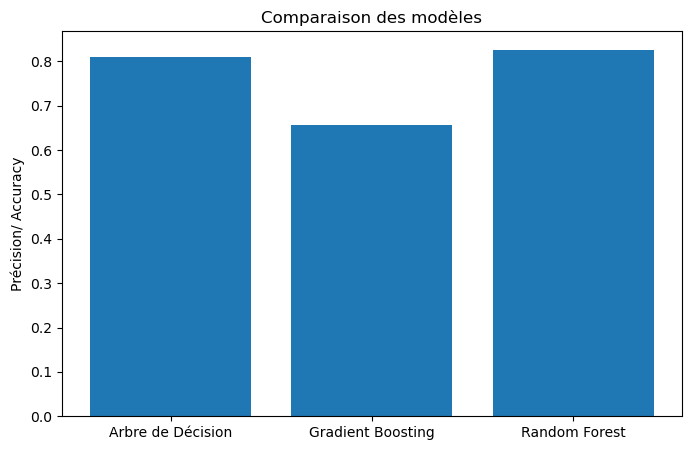

In [58]:

# =========================
# Visualisation des résultats
# =========================
noms_modeles = [
    "Arbre de Décision",
    "Gradient Boosting",
    "Random Forest"
]

scores = [
    precision_arbre,
    precision_boosting,
    precision_foret
]

plt.figure(figsize=(8, 5))

plt.bar(
    noms_modeles,
    scores
)

plt.ylabel("Précision/ Accuracy")

plt.title(
    "Comparaison des modèles"
)

plt.show()
